In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/features_output.csv")
df_numeric = df.drop(columns=["clue_id", "transcript"], errors="ignore")

## Correlations with Confidence

In [7]:
# Compute correlations with confidence & sort 
corr = df_numeric.corr(numeric_only=True)
confidence_corr = corr["confidence"].drop("confidence")
confidence_corr = confidence_corr.reindex(
    confidence_corr.abs().sort_values(ascending=False).index
)

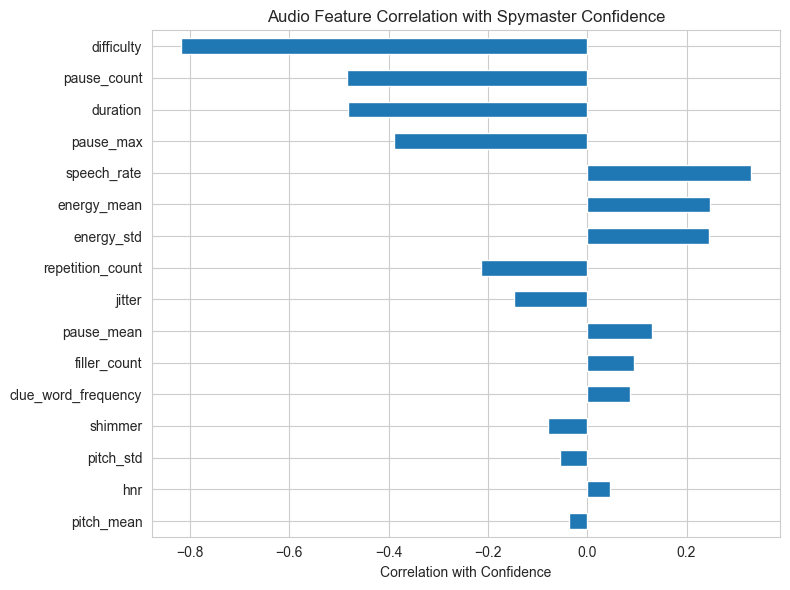

In [9]:
# plot correlation
plt.figure(figsize=(8,6))

confidence_corr.plot(kind="barh")

plt.xlabel("Correlation with Confidence")
plt.title("Audio Feature Correlation with Spymaster Confidence")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Inspect top features

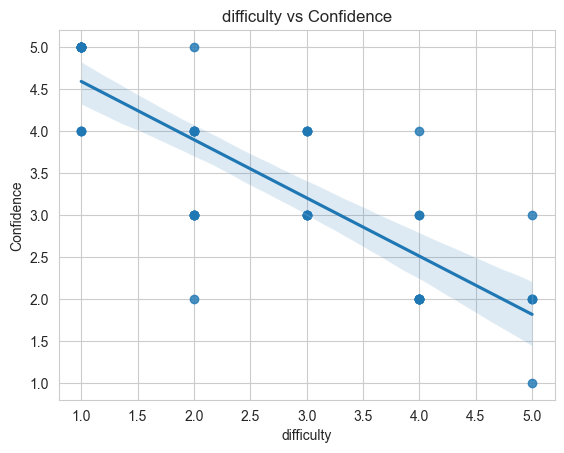

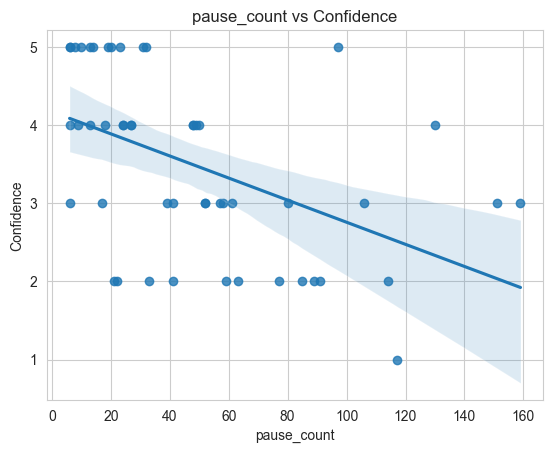

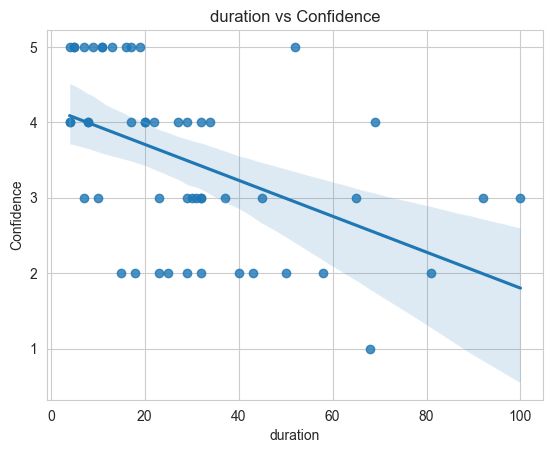

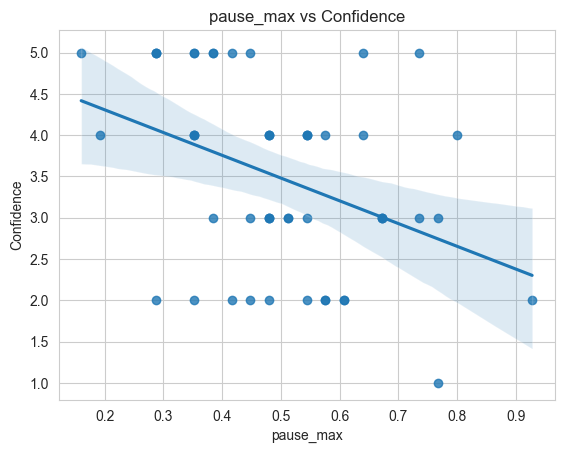

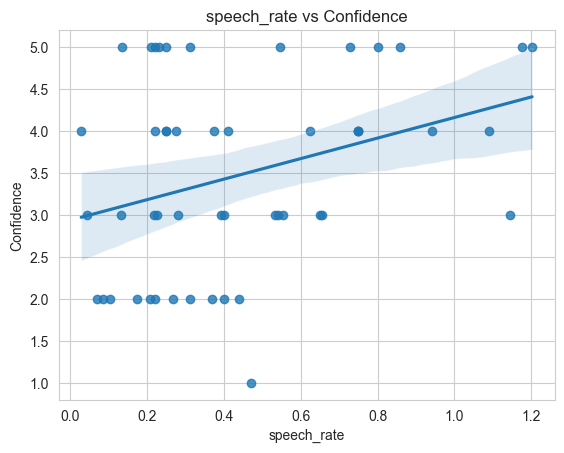

In [11]:
top_features = confidence_corr.abs().head(5).index

for feature in top_features:
    plt.figure()
    
    sns.regplot(x=df[feature], y=df["confidence"])
    
    plt.xlabel(feature)
    plt.ylabel("Confidence")
    
    plt.title(f"{feature} vs Confidence")
    
    plt.show()

## Correlations with Difficulty

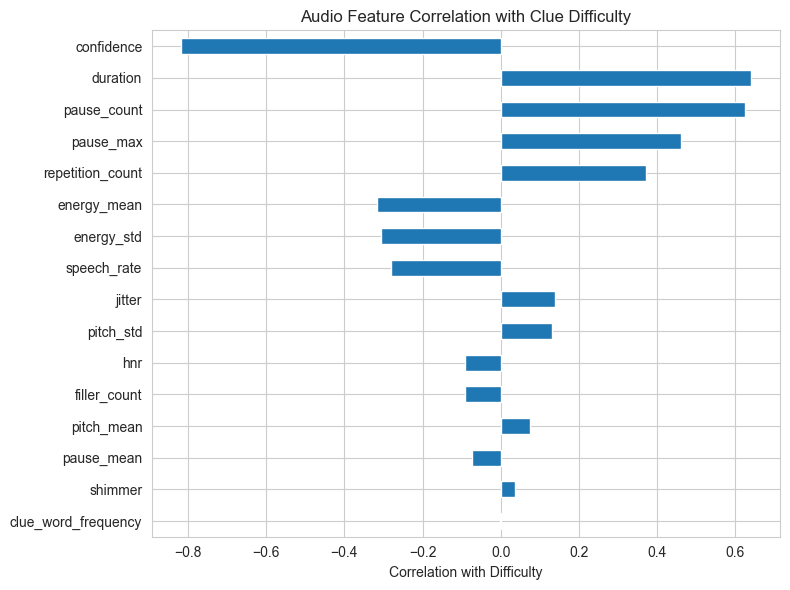

In [18]:
# Compute correlations with confidence & sort 
corr = df_numeric.corr(numeric_only=True)
confidence_corr = corr["difficulty"].drop("difficulty")
confidence_corr = confidence_corr.reindex(
    confidence_corr.abs().sort_values(ascending=False).index
)

# plot correlation
plt.figure(figsize=(8,6))

confidence_corr.plot(kind="barh")

plt.xlabel("Correlation with Difficulty")
plt.title("Audio Feature Correlation with Clue Difficulty")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Confidence Boxplots

In [ ]:
labels = ["confidence", "difficulty"]
non_features = ["clue_id", "transcript"]
feature_cols = [c for c in df.columns if c not in labels + non_features]

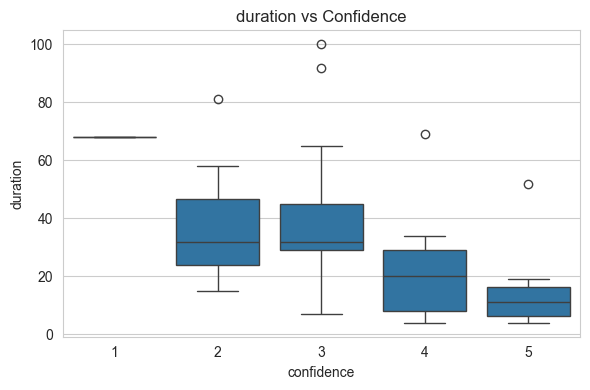

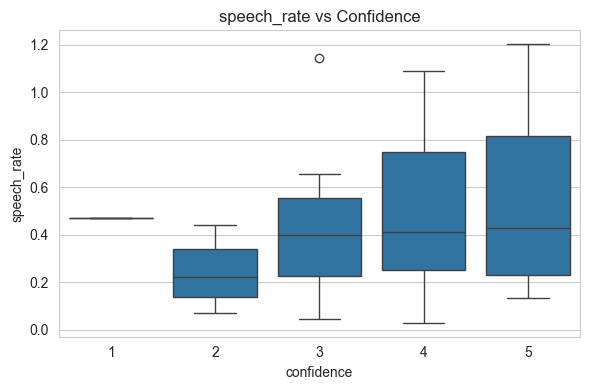

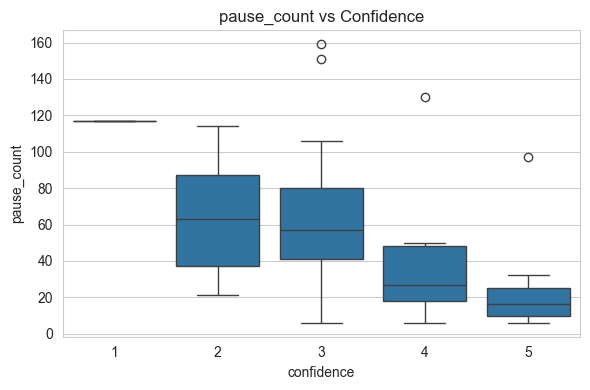

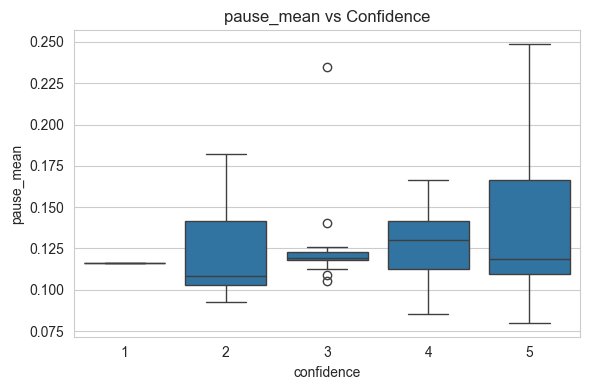

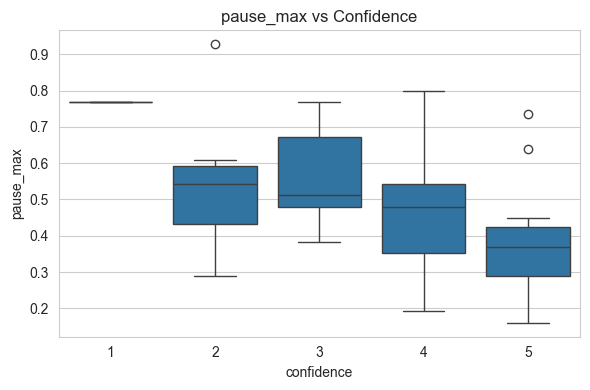

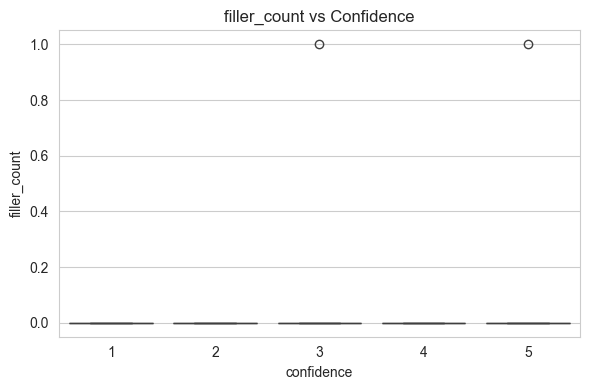

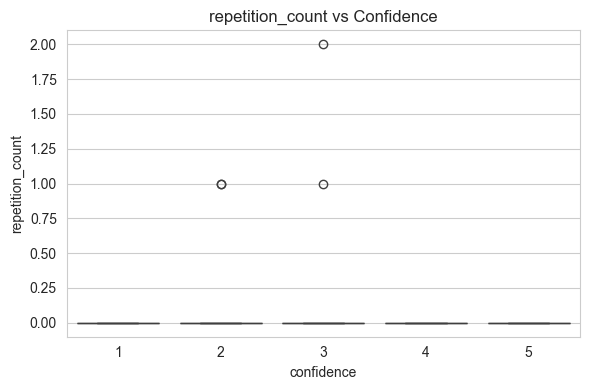

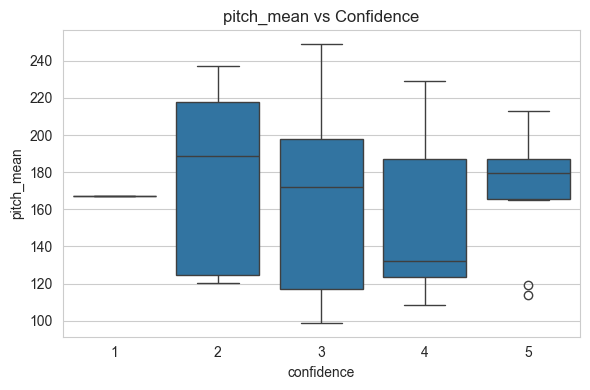

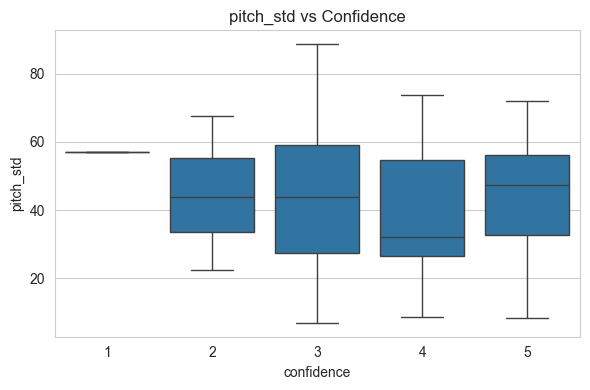

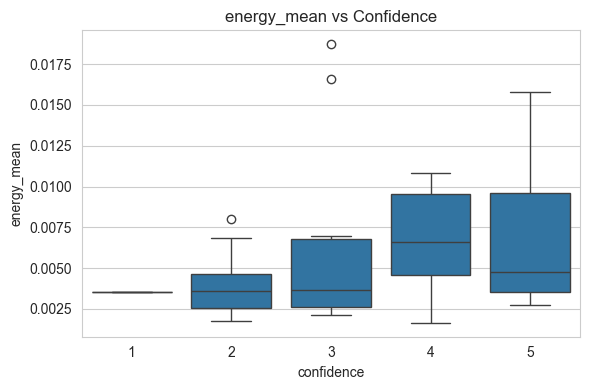

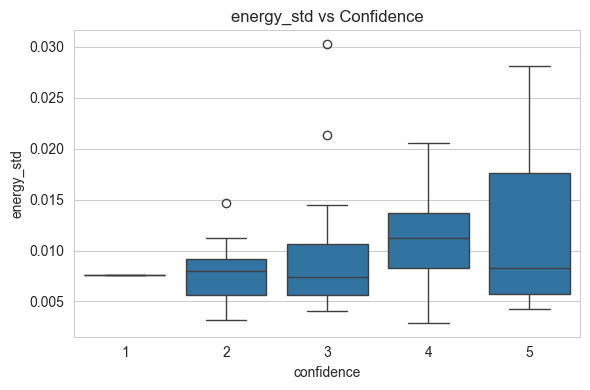

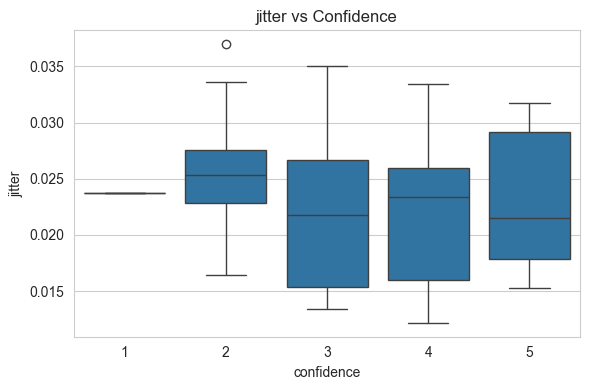

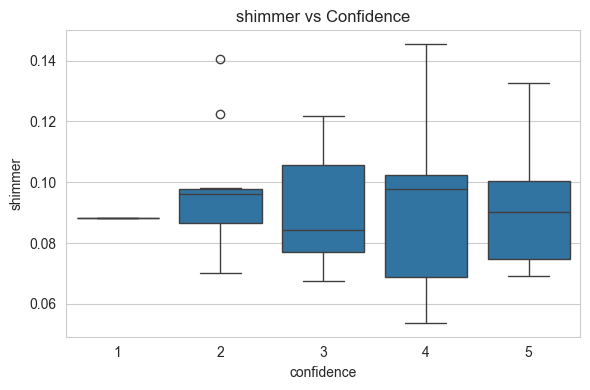

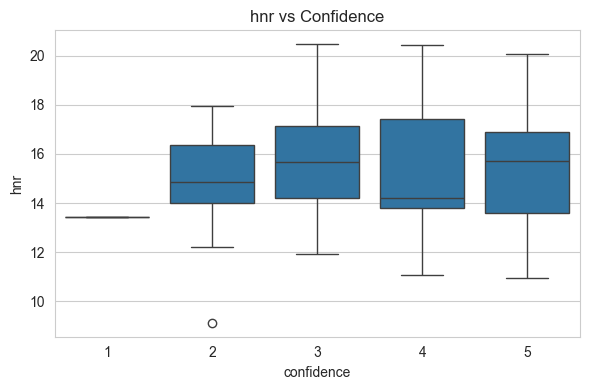

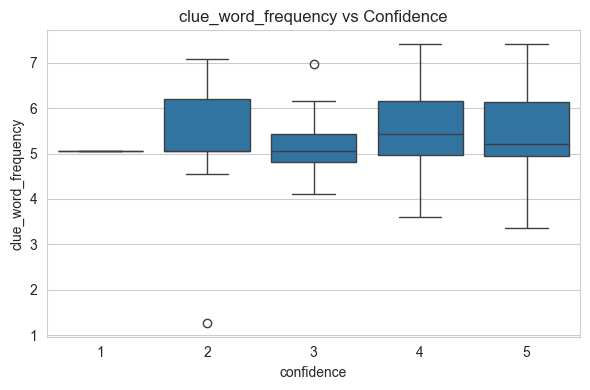

In [15]:
for feature in feature_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x="confidence", y=feature, data=df)

    plt.title(f"{feature} vs Confidence")

    plt.tight_layout()
    plt.show()

## Difficulty Boxplots

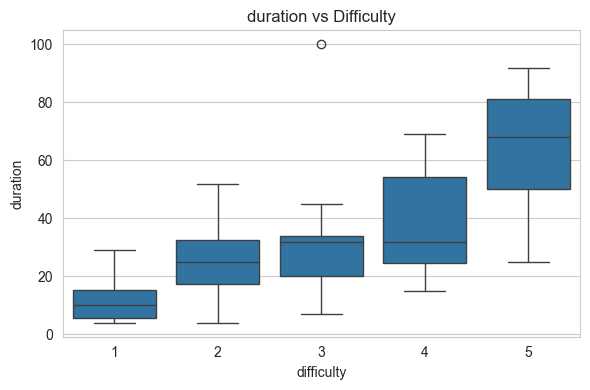

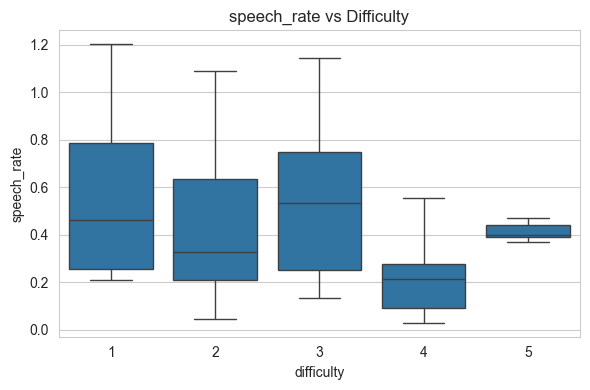

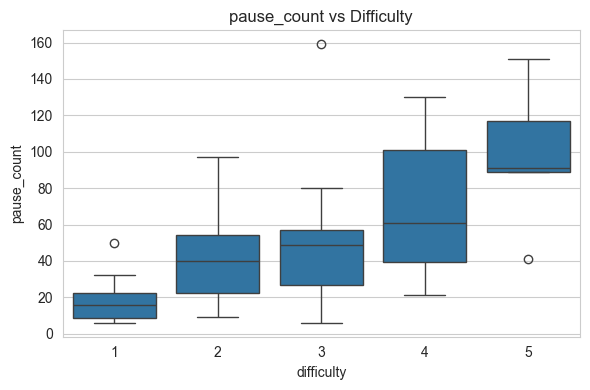

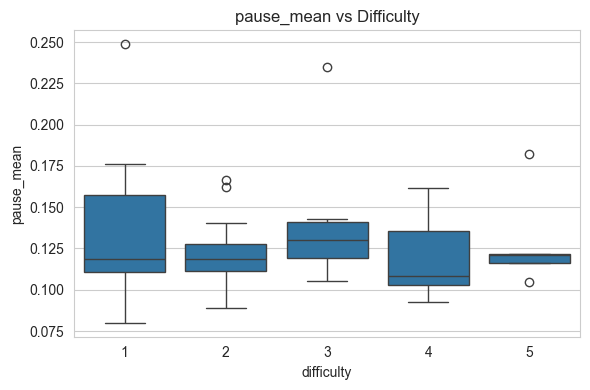

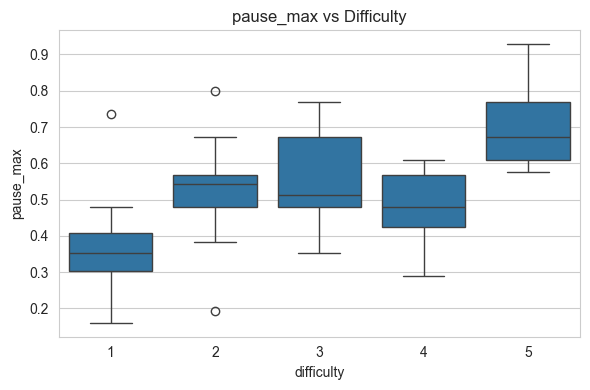

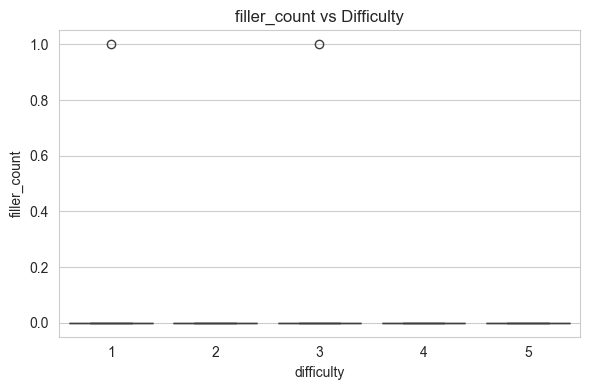

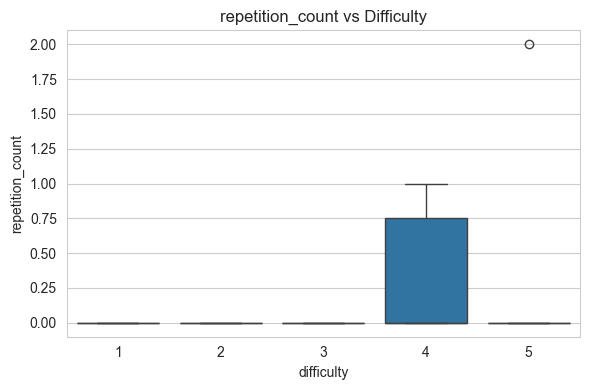

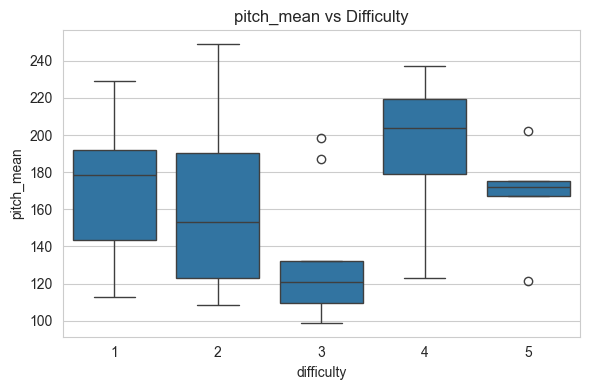

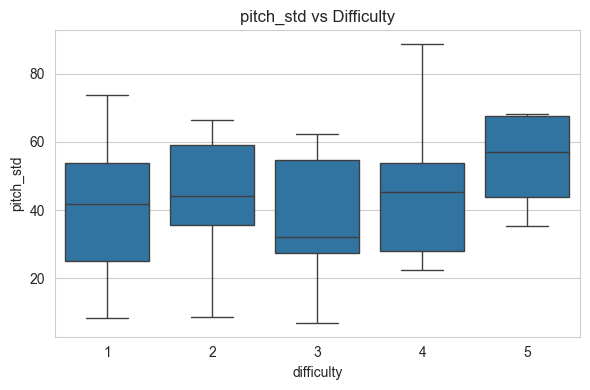

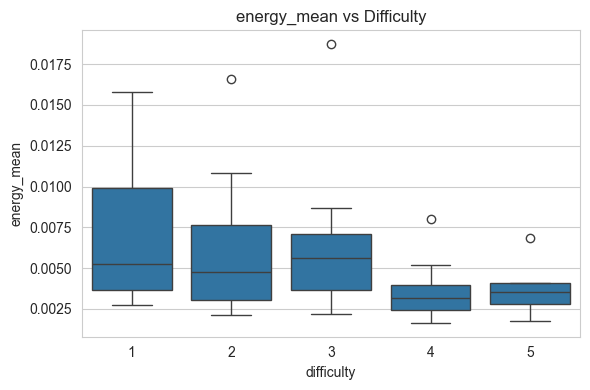

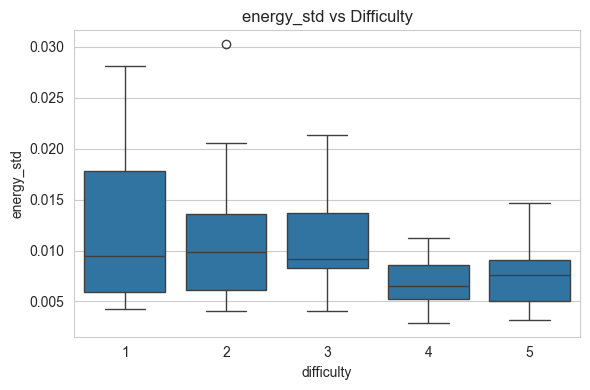

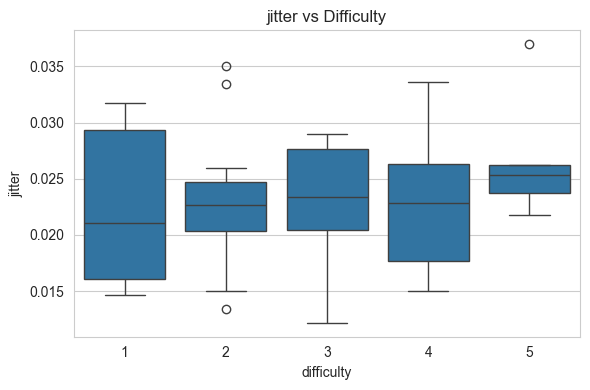

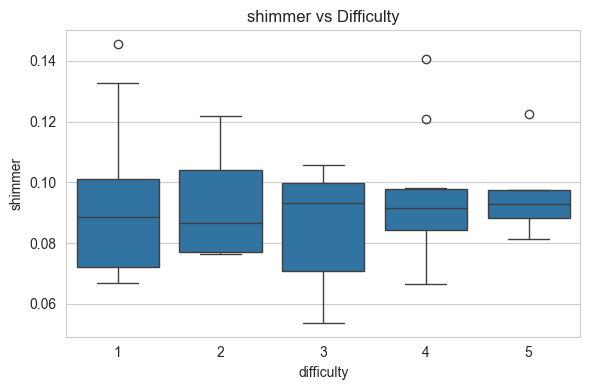

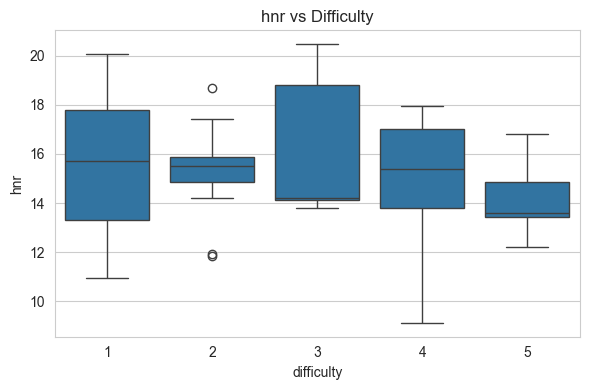

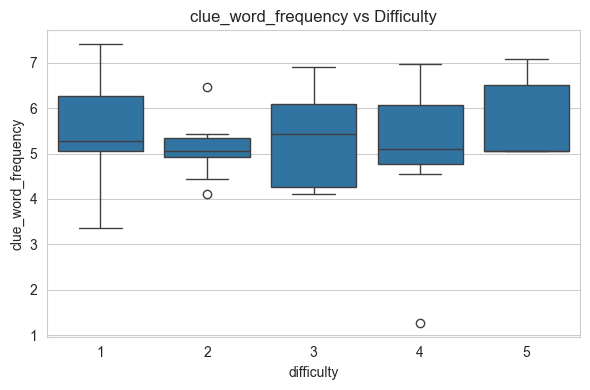

In [17]:
for feature in feature_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x="difficulty", y=feature, data=df)

    plt.title(f"{feature} vs Difficulty")

    plt.tight_layout()
    plt.show()